# Dependencies


In [76]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
import colorsys
import warnings
import folium
from folium.plugins import HeatMap, MarkerCluster

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=0.8)
sns.set_palette(sns.color_palette("deep"))
sns.set_theme(style="whitegrid")


# Dataset


In [77]:
df = pd.read_csv("../artifacts/data/02-preprocessed/train_df.csv")

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12107 entries, 0 to 12106
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           12107 non-null  int64  
 1   url                  12107 non-null  object 
 2   house_type           12107 non-null  object 
 3   bathrooms            12107 non-null  int64  
 4   bedrooms             12107 non-null  int64  
 5   price                12107 non-null  float64
 6   locality             12107 non-null  object 
 7   lat                  12107 non-null  float64
 8   lng                  12107 non-null  float64
 9   condition            12107 non-null  object 
 10  furnishing           12107 non-null  object 
 11  24_hour_electricity  12107 non-null  int64  
 12  air_conditioning     12107 non-null  int64  
 13  apartment            12107 non-null  int64  
 14  balcony              12107 non-null  int64  
 15  chandelier           12107 non-null 

In [79]:
df.head(2)

,Unnamed: 0,url,house_type,bathrooms,bedrooms,price,locality,lat,lng,condition,furnishing,24_hour_electricity,air_conditioning,apartment,balcony,chandelier,dining_area,dishwasher,hot_water,kitchen_cabinets,kitchen_shelf,microwave,pop_ceiling,pre_paid_meter,refrigerator,tv,tiled_floor,wardrobe,wi_fi
0,0,https://jiji.com.gh/spintex/houses-apartments-...,Apartment,2,2,2500.0,Spintex,5.637614,-0.126606,Used,Unfurnished,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0
1,1,https://jiji.com.gh/airport-residential-area/h...,Apartment,3,3,20000.0,Airport Residential Area,5.606105,-0.186036,Used,Furnished,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


# Plotting Functions


In [80]:
def plot_distribution(df, col,title=None):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(8,6))
    sns.histplot(
        df[col], bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax
    )
    median = df[col].median()
    ax.axvline(median, ls="--", lw=1.2, color="black")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    sns.despine(trim=True)
    ax.grid(False)
    ax.ticklabel_format(axis="x", style="plain")
    plt.title(title or f"Distribution of {col}")
    plt.show()

# Price Analysis


In [81]:
df.price.describe().T

count     12107.000000
mean      10868.640373
std       15758.267161
min         175.000000
25%        2200.000000
50%        4500.000000
75%       12500.000000
max      180000.000000
Name: price, dtype: float64

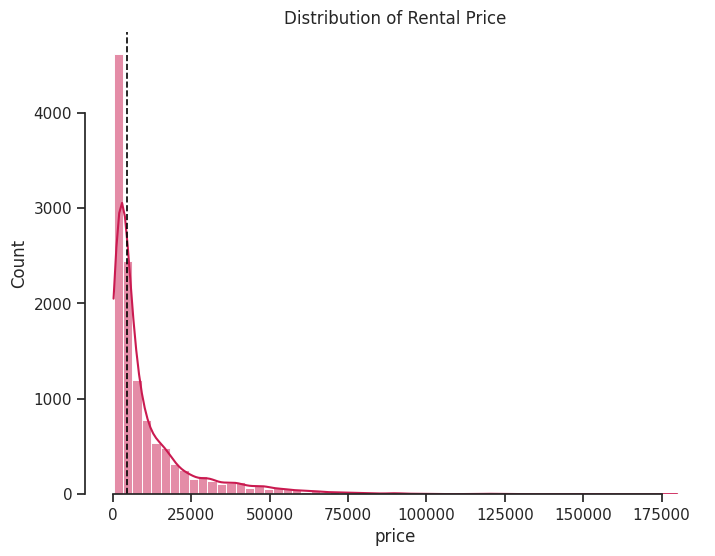

In [82]:
plot_distribution(df, "price", title="Distribution of Rental Price")

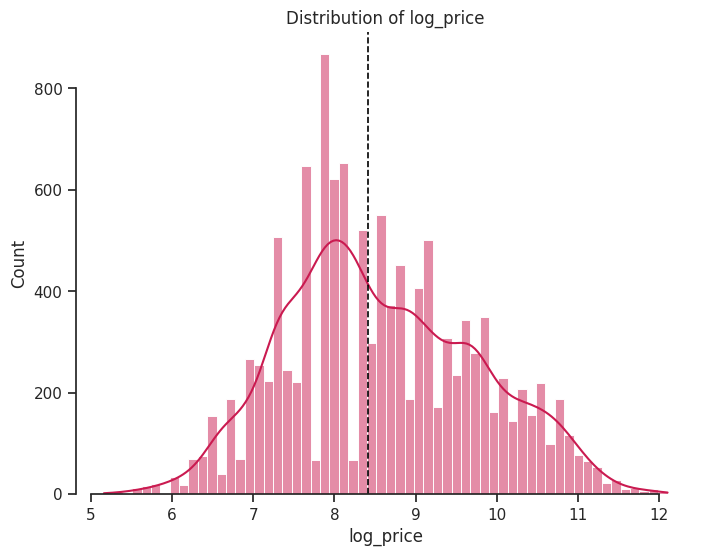

In [83]:
df['log_price']=np.log(df.price)
plot_distribution(df,'log_price')

# Location Analysis

In [84]:
top_cities = df['locality'].value_counts().head(20).index
df_top_cities = df[df['locality'].isin(top_cities)]['locality'].value_counts().to_frame().reset_index()
df_top_cities

,locality,count
0,East Legon,1368
1,Teshie,983
2,Spintex,948
3,Adenta,693
4,Accra Metropolitan,668
5,Tema Metropolitan,637
6,Ashaley Botwe,488
7,Adjiriganor,445
8,Airport Residential Area,443
9,Weija,419
